# Exercise: Optimization for SVM - Proximal Gradient vs. Gradient Descent


In this exercise, you'll compare two optimization methods for training a linear Support Vector Machine (SVM):

- **Proximal Gradient Descent** for standard (non-smooth) hinge loss.
- **Gradient Descent** for a **smoothed** hinge loss (Huberized or soft hinge).

You will:
- Implement both optimization methods.
- Visualize training loss over iterations.
- Plot and compare decision boundaries.


## Step 1: Generate and Prepare the Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate synthetic data
X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, class_sep=1.5,
                           random_state=42)
y = 2 * y - 1  # Convert labels to {-1, 1}

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 2: Define Loss Functions

In [2]:
def hinge_loss(w, X, y, lambd):
    margins = 1 - y * (X @ w)
    loss = np.maximum(0, margins)
    return np.mean(loss) + (lambd / 2) * np.linalg.norm(w) ** 2

def smooth_hinge(z, delta=0.1):
    loss = np.where(z >= 1, 0,
                    np.where(z >= 1 - delta, ((1 - z) ** 2) / (2 * delta), 1 - z - delta / 2))
    return loss

def smooth_hinge_grad(z, delta=0.1):
    grad = np.where(z >= 1, 0,
                    np.where(z >= 1 - delta, -(1 - z) / delta, -1))
    return grad


## Step 3: Implement Proximal Gradient Descent


Fill in the function below to implement Proximal Gradient Descent for optimizing hinge loss.


In [3]:
def prox_gradient_descent(X, y, lambd=0.1, lr=0.01, max_iter=100):
    n, d = X.shape
    w = np.random.randn(d) * 0.01  # Better initialization
    losses = []
    
    for iter in range(max_iter):
        margins = y * (X @ w)
        subgrad = np.where(margins >= 1, 0, -y)
        grad_reg = lambd * w
        grad = X.T @ subgrad / n + grad_reg
        w = w - lr * grad
        current_loss = hinge_loss(w, X, y, lambd)
        losses.append(current_loss)
            
    return w, losses



## Step 4: Implement Gradient Descent on Smoothed Hinge Loss



Now implement gradient descent using the smoothed hinge loss.


In [4]:
def smoothed_gradient_descent(X, y, lambd=0.1, lr=0.01, max_iter=100, delta=0.1):
    n, d = X.shape
    w = np.random.randn(d) * 0.01  # Better initialization
    losses = []
    
    for iter in range(max_iter):
        margins = y * (X @ w)
        grad_hinge = smooth_hinge_grad(margins, delta)
        grad_reg = lambd * w
        grad = X.T @ (grad_hinge * y) / n + grad_reg
        w = w - lr * grad
        current_loss = np.mean(smooth_hinge(margins, delta)) + (lambd / 2) * np.linalg.norm(w) ** 2
        losses.append(current_loss)
    return w, losses


## Step 5: Train Models and Plot Training Loss

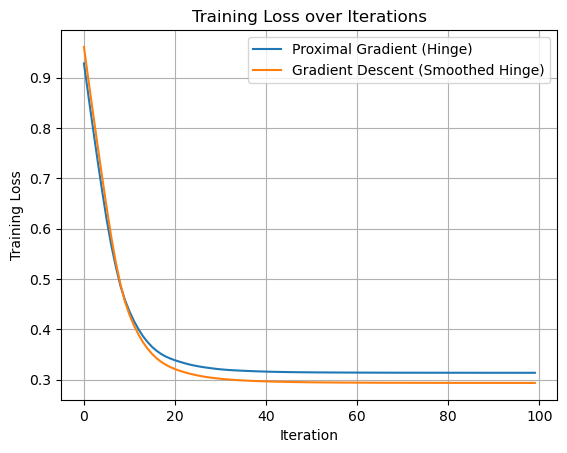

In [5]:
lambd = 0.1
lr = 0.1
max_iter = 100

# Uncomment after implementation
w_prox, loss_prox = prox_gradient_descent(X_train, y_train, lambd, lr, max_iter)
w_smooth, loss_smooth = smoothed_gradient_descent(X_train, y_train, lambd, lr, max_iter)

# TODO: Plot loss curves
plt.plot(loss_prox, label='Proximal Gradient (Hinge)')
plt.plot(loss_smooth, label='Gradient Descent (Smoothed Hinge)')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()


## Step 6: Plot Decision Boundaries

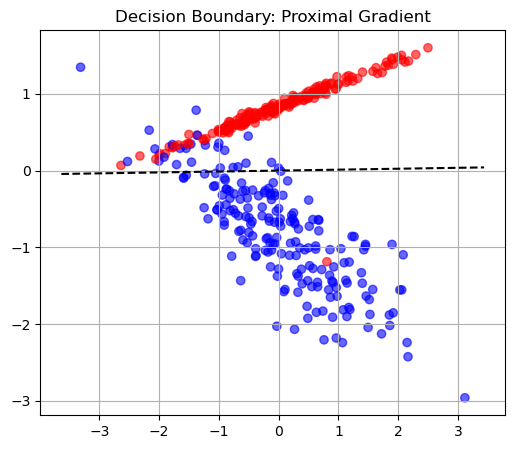

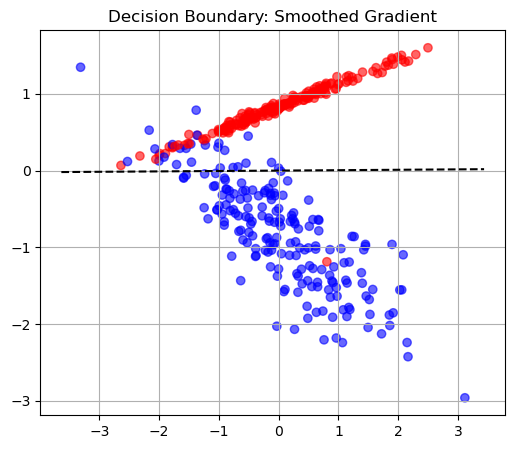

In [6]:
def plot_decision_boundary(w, X, y, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
    ax = plt.gca()
    x_vals = np.array(ax.get_xlim())
    y_vals = -(w[0] * x_vals) / w[1]
    plt.plot(x_vals, y_vals, 'k--')
    plt.title(title)
    plt.grid(True)
    plt.show()

# TODO: Call plot_decision_boundary for both models
plot_decision_boundary(w_prox, X_train, y_train, 'Decision Boundary: Proximal Gradient')
plot_decision_boundary(w_smooth, X_train, y_train, 'Decision Boundary: Smoothed Gradient')
